In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configurar el estilo visual por defecto
sns.set_theme(style="whitegrid")

# Cargar datos si no lo has hecho
df = pd.read_csv('https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/netflix_titles.csv')

# --- LIMPIEZA ESENCIAL PARA GRÁFICOS ---
df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.strftime('%B')

# Extraer duración numérica solo para películas
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration_num'] = df_movies['duration'].str.extract(r'(\d+)').astype(float)

# Explotar géneros para las partes que lo requieran
df_exploded = df.copy()
df_exploded['listed_in'] = df_exploded['listed_in'].str.split(', ')
df_exploded = df_exploded.explode('listed_in')

Parte 1

/tmp/ipykernel_1317/309453208.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', ax=axes[0], palette='Set2')


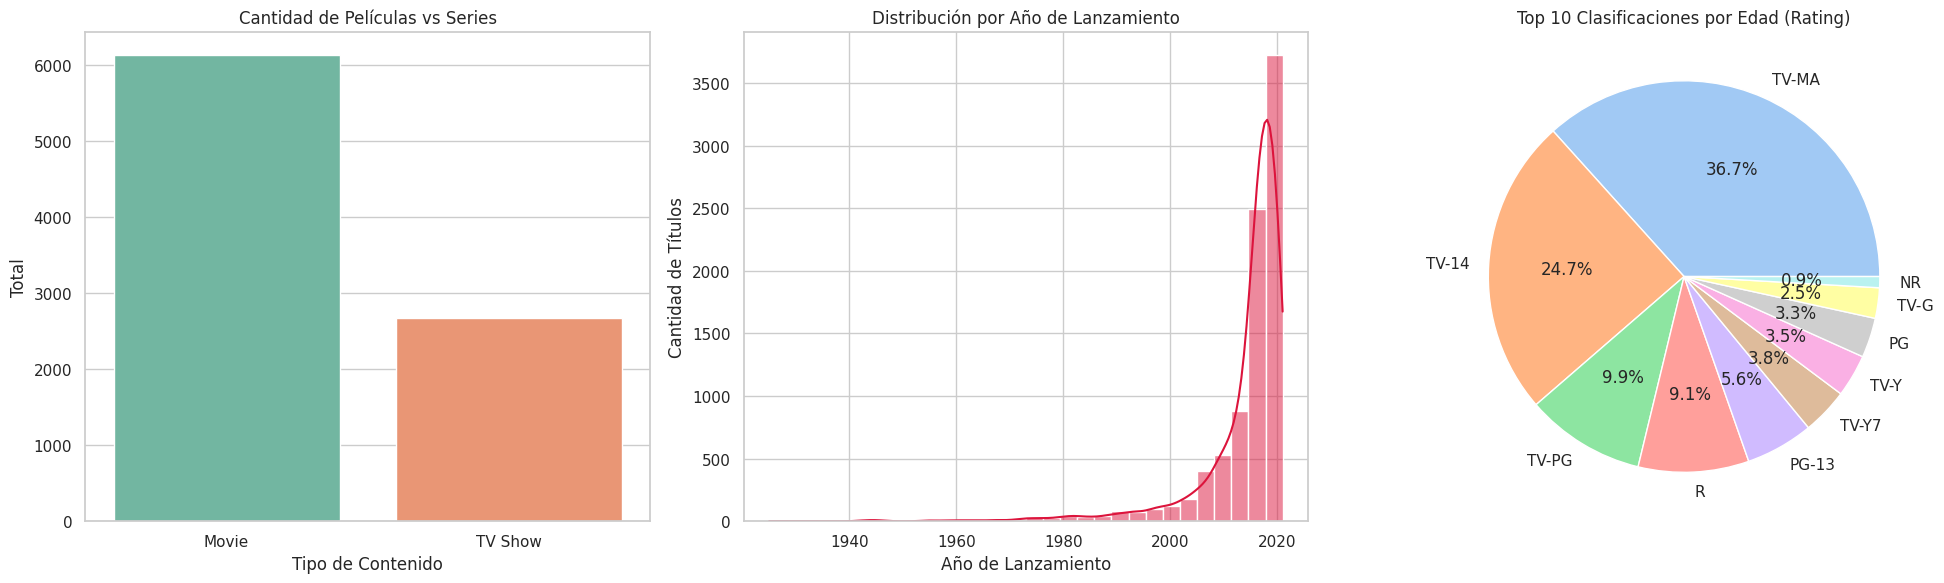

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Distribución de tipos de contenido
sns.countplot(data=df, x='type', ax=axes[0], palette='Set2')
axes[0].set_title('Cantidad de Películas vs Series')
axes[0].set_xlabel('Tipo de Contenido')
axes[0].set_ylabel('Total')

# 2. Histogramas de años de lanzamiento
sns.histplot(data=df, x='release_year', bins=30, ax=axes[1], kde=True, color='crimson')
axes[1].set_title('Distribución por Año de Lanzamiento')
axes[1].set_xlabel('Año de Lanzamiento')
axes[1].set_ylabel('Cantidad de Títulos')

# 3. Proporción de clasificaciones por edad (Top 10 Ratings)
top_ratings = df['rating'].value_counts().head(10)
axes[2].pie(top_ratings.values, labels=top_ratings.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[2].set_title('Top 10 Clasificaciones por Edad (Rating)')

plt.tight_layout()
plt.show()

El contenido predominante son las Películas. Hay una concentración masiva de títulos recientes (post-2015). Las clasificaciones dominantes como TV-MA y TV-14 demuestran que Netflix enfoca fuertemente su catálogo hacia un público adulto y adolescente.

Parte 2

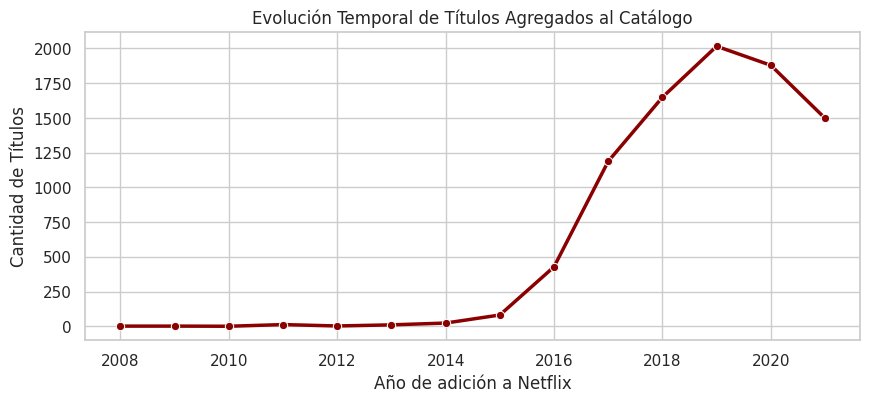

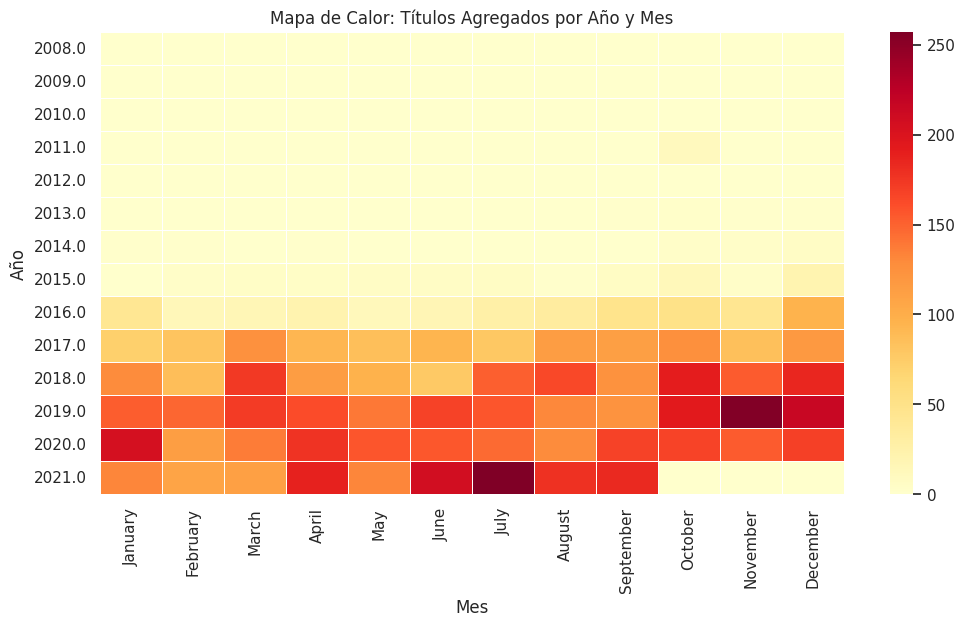

/tmp/ipykernel_1317/1119280286.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered_genres, x='duration_num', y='listed_in', palette='vlag', fliersize=2)


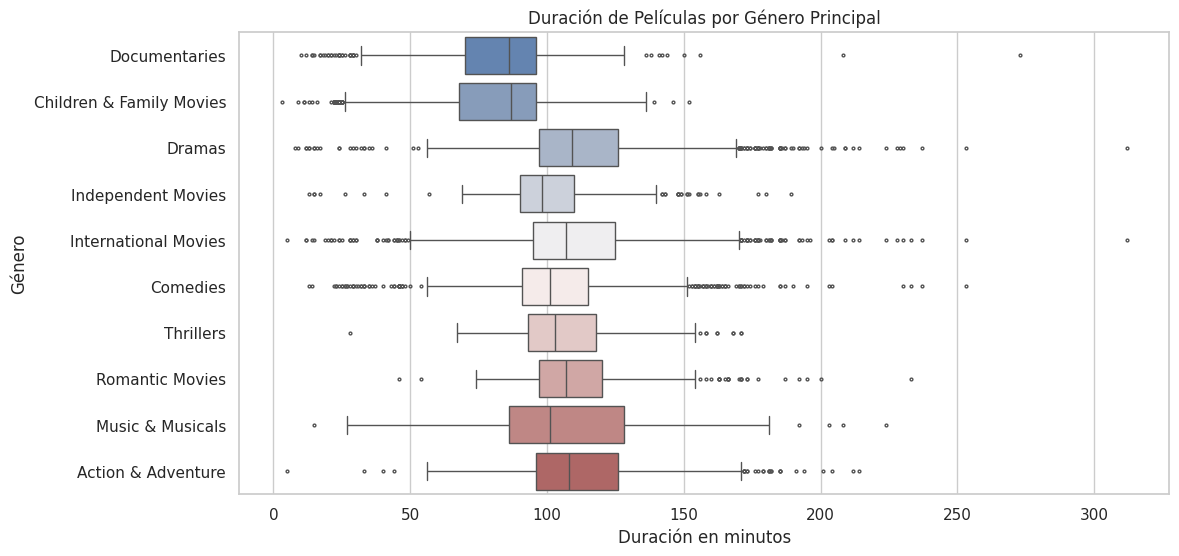

In [3]:
# 1. Número de títulos agregados por año (Línea de tiempo)
plt.figure(figsize=(10, 4))
titulos_por_ano = df['year_added'].value_counts().sort_index()
sns.lineplot(x=titulos_por_ano.index, y=titulos_por_ano.values, marker='o', color='darkred', linewidth=2.5)
plt.title('Evolución Temporal de Títulos Agregados al Catálogo')
plt.xlabel('Año de adición a Netflix')
plt.ylabel('Cantidad de Títulos')
plt.show()

# 2. Heatmap de lanzamientos por año y mes
# Ordenar los meses cronológicamente para el mapa
meses_ordenados = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
heatmap_data = df.groupby(['year_added', 'month_added']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(columns=meses_ordenados)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt='d', linewidths=.5)
plt.title('Mapa de Calor: Títulos Agregados por Año y Mes')
plt.xlabel('Mes')
plt.ylabel('Año')
plt.show()

# 3. Duración de películas por género principal (Top 10 géneros de películas)
df_movies_exploded = df_movies.copy()
df_movies_exploded['listed_in'] = df_movies_exploded['listed_in'].str.split(', ')
df_movies_exploded = df_movies_exploded.explode('listed_in')
top_movie_genres = df_movies_exploded['listed_in'].value_counts().head(10).index
df_filtered_genres = df_movies_exploded[df_movies_exploded['listed_in'].isin(top_movie_genres)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered_genres, x='duration_num', y='listed_in', palette='vlag', fliersize=2)
plt.title('Duración de Películas por Género Principal')
plt.xlabel('Duración en minutos')
plt.ylabel('Género')
plt.show()

El catálogo explotó exponencialmente entre 2017 y 2019, coincidiendo con su expansión global. No hay una estacionalidad drástica mes a mes, pero los meses de fin de año suelen cargarse un poco más. Los géneros como Dramas y International Movies muestran duraciones más largas y estables en torno a los 100-110 minutos, mientras que las películas infantiles (Children & Family) son marcadamente más cortas.

Parte 3

/tmp/ipykernel_1317/2056869116.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0], palette='viridis')


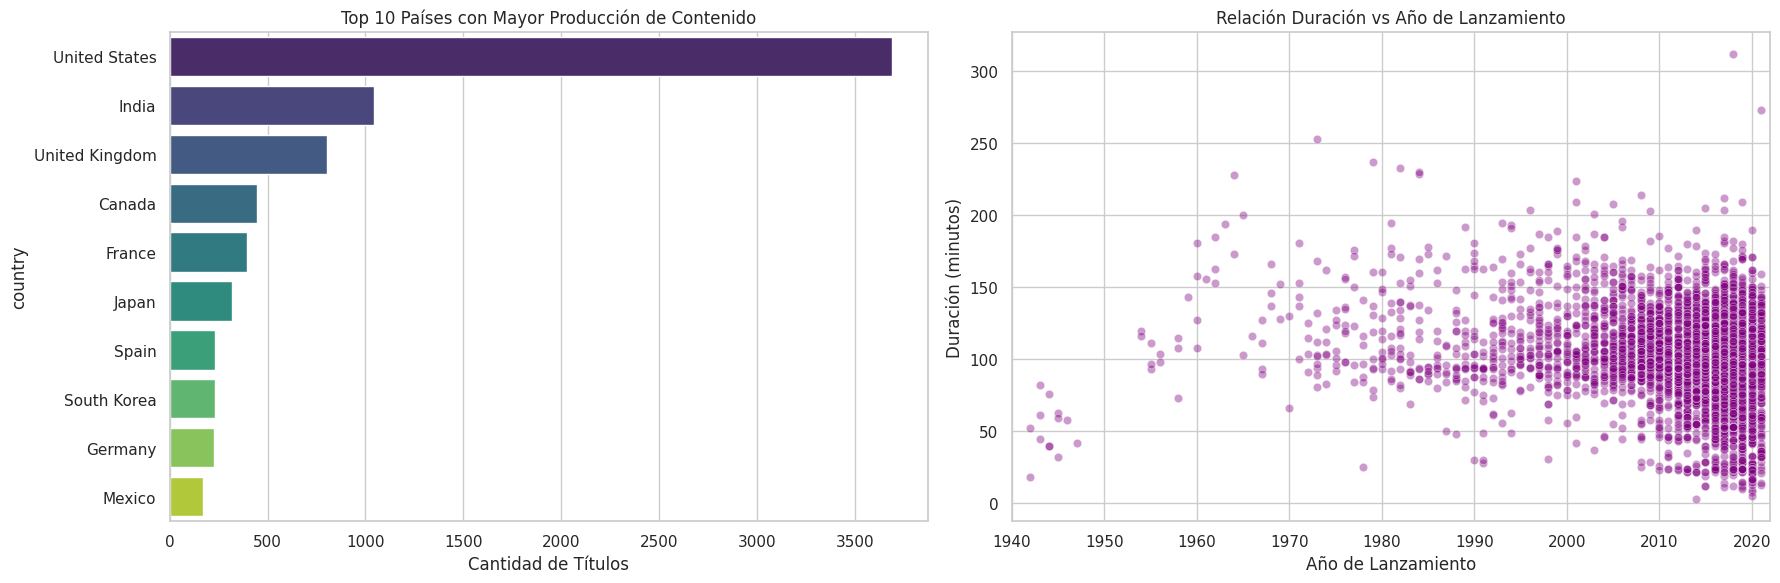

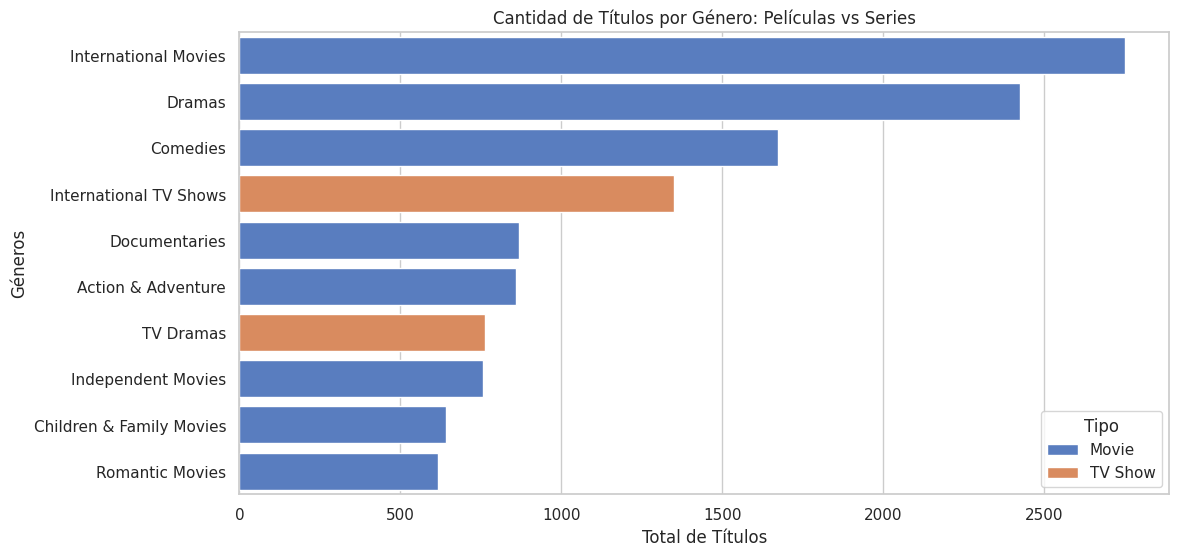

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Top 10 países con más producciones (Limpiando países múltiples)
df_countries = df.copy()
df_countries['country'] = df_countries['country'].str.split(', ')
df_countries = df_countries.explode('country')
top_countries = df_countries['country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Países con Mayor Producción de Contenido')
axes[0].set_xlabel('Cantidad de Títulos')

# 2. Relación entre duración y año de lanzamiento
sns.scatterplot(data=df_movies, x='release_year', y='duration_num', alpha=0.4, color='purple', ax=axes[1])
axes[1].set_title('Relación Duración vs Año de Lanzamiento')
axes[1].set_xlabel('Año de Lanzamiento')
axes[1].set_ylabel('Duración (minutos)')
axes[1].set_xlim(1940, 2022) # Acotamos para ver mejor la tendencia histórica

plt.tight_layout()
plt.show()

# 3. Películas vs Series según género (Barras apiladas/agrupadas)
top_10_generos_totales = df_exploded['listed_in'].value_counts().head(10).index
df_plot_genres = df_exploded[df_exploded['listed_in'].isin(top_10_generos_totales)]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_plot_genres, y='listed_in', hue='type', palette='muted', order=top_10_generos_totales)
plt.title('Cantidad de Títulos por Género: Películas vs Series')
plt.xlabel('Total de Títulos')
plt.ylabel('Géneros')
plt.legend(title='Tipo')
plt.show()

Parte 3

/tmp/ipykernel_1317/2056869116.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0], palette='viridis')


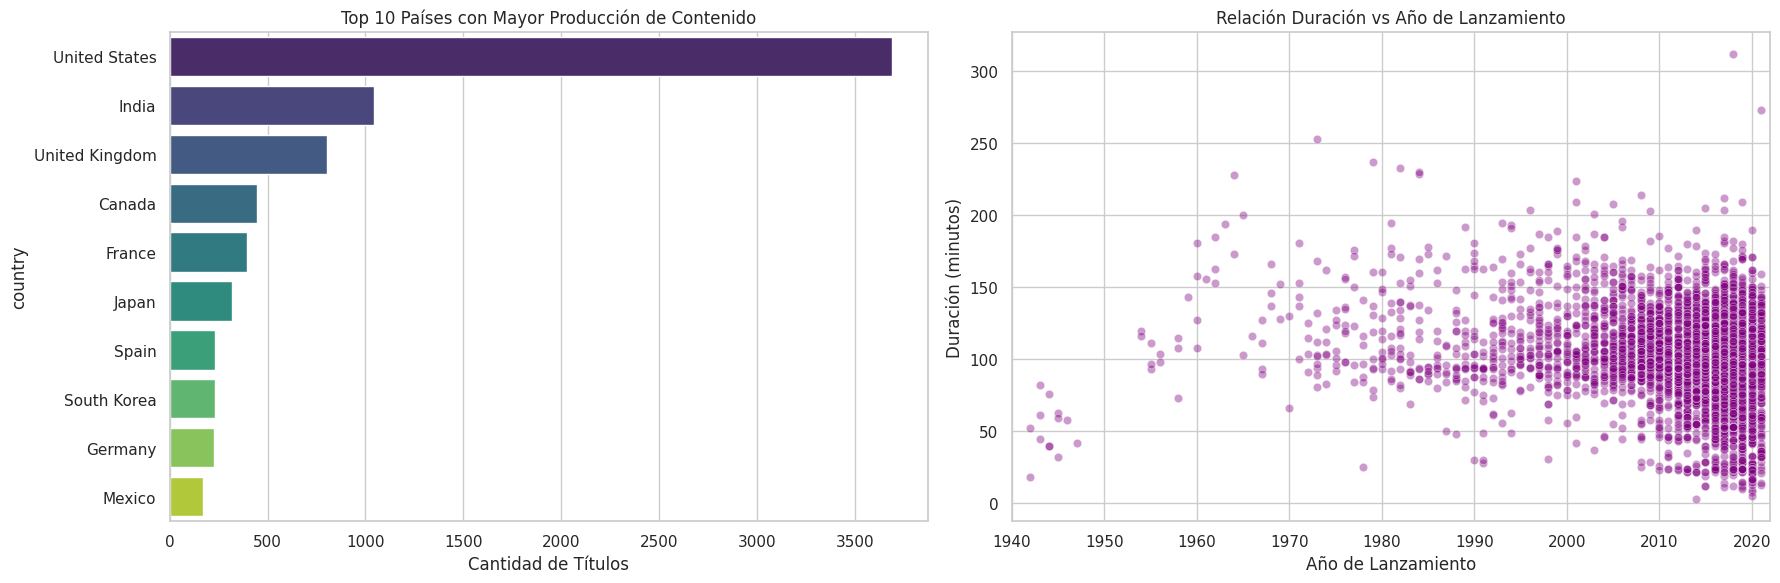

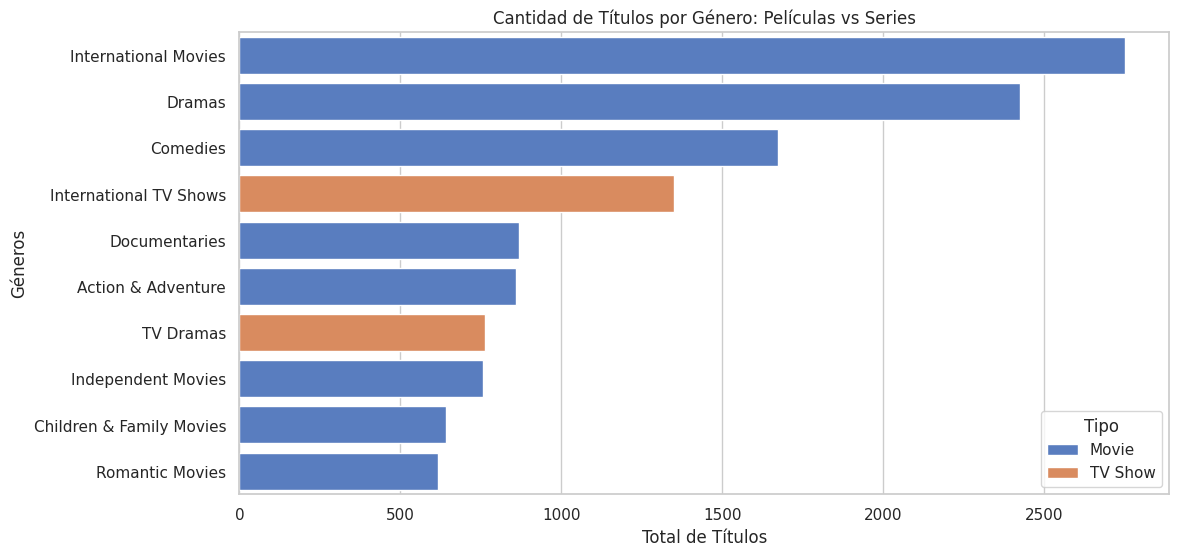

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Top 10 países con más producciones (Limpiando países múltiples)
df_countries = df.copy()
df_countries['country'] = df_countries['country'].str.split(', ')
df_countries = df_countries.explode('country')
top_countries = df_countries['country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Países con Mayor Producción de Contenido')
axes[0].set_xlabel('Cantidad de Títulos')

# 2. Relación entre duración y año de lanzamiento
sns.scatterplot(data=df_movies, x='release_year', y='duration_num', alpha=0.4, color='purple', ax=axes[1])
axes[1].set_title('Relación Duración vs Año de Lanzamiento')
axes[1].set_xlabel('Año de Lanzamiento')
axes[1].set_ylabel('Duración (minutos)')
axes[1].set_xlim(1940, 2022) # Acotamos para ver mejor la tendencia histórica

plt.tight_layout()
plt.show()

# 3. Películas vs Series según género (Barras apiladas/agrupadas)
top_10_generos_totales = df_exploded['listed_in'].value_counts().head(10).index
df_plot_genres = df_exploded[df_exploded['listed_in'].isin(top_10_generos_totales)]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_plot_genres, y='listed_in', hue='type', palette='muted', order=top_10_generos_totales)
plt.title('Cantidad de Títulos por Género: Películas vs Series')
plt.xlabel('Total de Títulos')
plt.ylabel('Géneros')
plt.legend(title='Tipo')
plt.show()

Estados Unidos e India dominan ampliamente el catálogo. Históricamente, la duración de las películas se ha estandarizado fuertemente en un bloque compacto entre los 80 y 120 minutos, detectándose outliers salvajes (películas de más de 3 horas) principalmente en las últimas décadas. Ciertos géneros como Docuseries o Anime Series pertenecen estrictamente a Shows de TV, mientras que las producciones internacionales se vuelcan mucho más a películas.

Desafio final

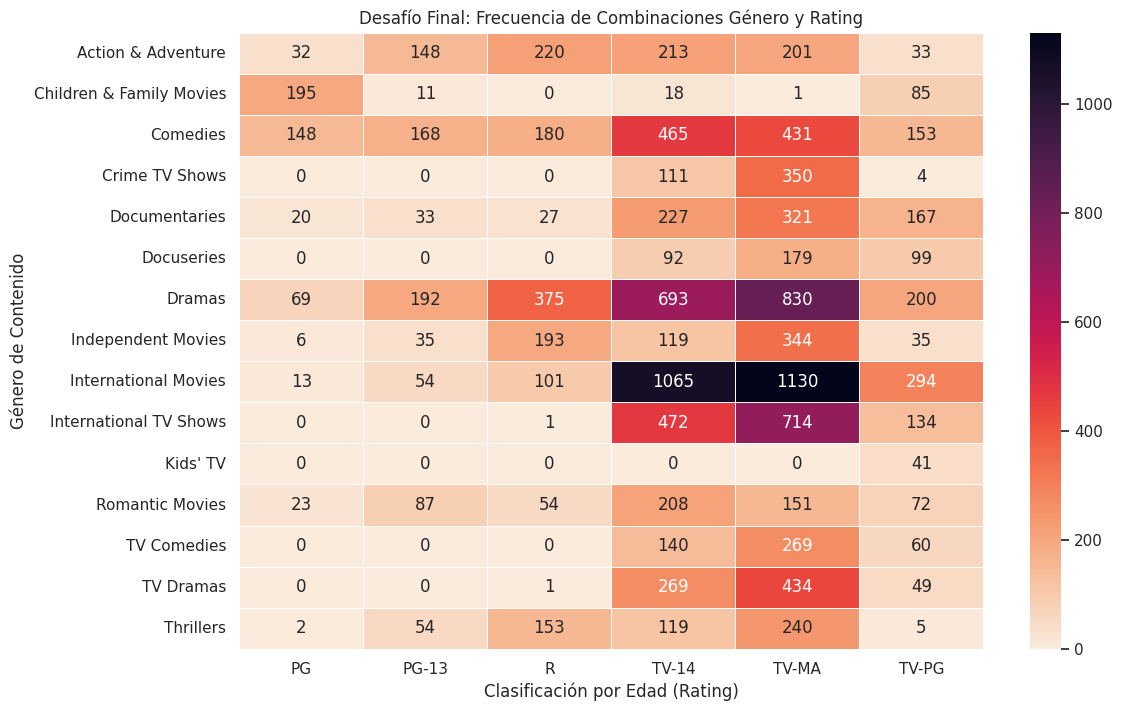

In [6]:
# Filtrar top 15 géneros y top 6 ratings más comunes para que el mapa de calor sea legible
top_genres = df_exploded['listed_in'].value_counts().head(15).index
top_ratings = df_exploded['rating'].value_counts().head(6).index

df_desafio = df_exploded[df_exploded['listed_in'].isin(top_genres) & df_exploded['rating'].isin(top_ratings)]

# Matriz de frecuencias cruzadas
cross_matrix = pd.crosstab(df_desafio['listed_in'], df_desafio['rating'])

plt.figure(figsize=(12, 8))
sns.heatmap(cross_matrix, cmap='rocket_r', annot=True, fmt='d', linewidths=.5)
plt.title('Desafío Final: Frecuencia de Combinaciones Género y Rating')
plt.xlabel('Clasificación por Edad (Rating)')
plt.ylabel('Género de Contenido')
plt.show()

Queda en evidencia que los géneros de Dramas, Comedias e International Movies van directamente ligados a públicos maduros (TV-MA) o adolescentes (TV-14), mientras que géneros específicos como Children & Family Movies concentran todo el volumen de clasificaciones aptas para todo público (TV-G / PG).

¡Con esto tienes todo tu laboratorio resuelto con gráficos limpios y profesionales! Avísame si quieres personalizar los colores de algún gráfico en particular.